In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [8]:
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import roc_auc_score, precision_score, recall_score
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/alexeygrigorev/datasets/master/course_lead_scoring.csv')

In [3]:
df

,lead_source,industry,number_of_courses_viewed,annual_income,employment_status,location,interaction_count,lead_score,converted
0,paid_ads,NaN,1,79450.0,unemployed,south_america,4,0.94,1
1,social_media,retail,1,46992.0,employed,south_america,1,0.80,0
2,events,healthcare,5,78796.0,unemployed,australia,3,0.69,1
3,paid_ads,retail,2,83843.0,NaN,australia,1,0.87,0
4,referral,education,3,85012.0,self_employed,europe,3,0.62,1
...,...,...,...,...,...,...,...,...,...
1457,referral,manufacturing,1,NaN,self_employed,north_america,4,0.53,1
1458,referral,technology,3,65259.0,student,europe,2,0.24,1
1459,paid_ads,technology,1,45688.0,student,north_america,3,0.02,1
1460,referral,NaN,5,71016.0,self_employed,north_america,0,0.25,1


# Data Preparation

In [9]:
# Nome da coluna alvo (y)
target_col = "converted"
if target_col not in df.columns:
    raise ValueError(f"Coluna alvo '{target_col}' não encontrada no dataset. Verifique o nome no CSV.")

# Verificação de ausentes antes do tratamento
print("Quantidade de valores ausentes ANTES do tratamento:")
display(df.isna().sum().sort_values(ascending=False))

# Detecta tipos
cat_cols = [c for c in df.columns if df[c].dtype == 'object' and c != target_col]
num_cols = [c for c in df.columns if (np.issubdtype(df[c].dtype, np.number)) and c != target_col]

# Tratamento de ausentes
df[cat_cols] = df[cat_cols].fillna('NA')
df[num_cols] = df[num_cols].fillna(0.0)

print("\nQuantidade de valores ausentes DEPOIS do tratamento:")
display(df.isna().sum().sort_values(ascending=False))

# Normaliza a coluna alvo para 0/1
y_raw = df[target_col]
if y_raw.dtype == 'object':
    # tenta mapear yes/no, y/n, etc.
    y = y_raw.str.lower().map({'yes':1, 'no':0, 'y':1, 'n':0, 'true':1, 'false':0})
    if y.isna().any():
        # fallback: qualquer coisa diferente de 'no' vira 1
        y = (y_raw.astype(str).str.lower() != 'no').astype(int)
else:
    # se já é numérica/booleana
    if np.issubdtype(y_raw.dtype, np.number):
        # garante binário (0/1)
        y = (y_raw > 0).astype(int)
    else:
        y = y_raw.astype(int)

# Remove a coluna alvo do DF de features
X = df.drop(columns=[target_col])
all_feature_cols = list(X.columns)

# Split 60/20/20 com random_state=1
df_temp, df_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=1, stratify=y)
df_train, df_val, y_train, y_val = train_test_split(df_temp, y_temp, test_size=0.25, random_state=1, stratify=y_temp)  # 0.25 de 0.8 => 0.2

print(f"Tamanhos — train: {df_train.shape}, val: {df_val.shape}, test: {df_test.shape}")

Quantidade de valores ausentes ANTES do tratamento:


lead_source                 0
industry                    0
number_of_courses_viewed    0
annual_income               0
employment_status           0
location                    0
interaction_count           0
lead_score                  0
converted                   0
dtype: int64


Quantidade de valores ausentes DEPOIS do tratamento:


lead_source                 0
industry                    0
number_of_courses_viewed    0
annual_income               0
employment_status           0
location                    0
interaction_count           0
lead_score                  0
converted                   0
dtype: int64

Tamanhos — train: (876, 8), val: (293, 8), test: (293, 8)


# Q1

In [10]:
# =========================
# Bloco 2 — Q1: Importância via ROC AUC (variáveis numéricas)
# =========================

candidatas = [
    "lead_score",
    "number_of_courses_viewed",
    "interaction_count",
    "annual_income",
]

presentes = [c for c in candidatas if c in df_train.columns and np.issubdtype(df_train[c].dtype, np.number)]
if not presentes:
    raise ValueError("Nenhuma das variáveis candidatas para Q1 foi encontrada como numérica no dataset.")

aucs = {}

for col in presentes:
    s = df_train[col].values
    # Se todos valores forem iguais, AUC não é definida; pula
    if np.all(s == s[0]):
        print(f"Atenção: {col} possui valor constante; ignorando.")
        continue
    auc = roc_auc_score(y_train, s)
    if auc < 0.5:
        s = -s
        auc = roc_auc_score(y_train, s)
    aucs[col] = auc

if not aucs:
    raise ValueError("Nenhuma AUC válida pôde ser calculada na Q1 (todas constantes?).")

melhor_var = max(aucs, key=aucs.get)
print("AUC por variável (após possível inversão):")
for k, v in aucs.items():
    print(f"  {k}: {v:.5f}")

print(f"\n>>> Q1 — Variável com maior AUC: {melhor_var} (AUC={aucs[melhor_var]:.5f})")


AUC por variável (após possível inversão):
  lead_score: 0.61779
  number_of_courses_viewed: 0.75191
  interaction_count: 0.70573
  annual_income: 0.56747

>>> Q1 — Variável com maior AUC: number_of_courses_viewed (AUC=0.75191)


# Q2

In [11]:
# =========================
# Bloco 3 — Q2: One-Hot + Logistic Regression e AUC na Validação
# =========================

# Constrói lista de categóricas e numéricas novamente a partir de df_train
cat_cols = [c for c in df_train.columns if df_train[c].dtype == 'object']
num_cols = [c for c in df_train.columns if np.issubdtype(df_train[c].dtype, np.number)]

# DictVectorizer para One-Hot
dv = DictVectorizer(sparse=True)

train_dicts = df_train[cat_cols + num_cols].to_dict(orient='records')
val_dicts   = df_val[cat_cols + num_cols].to_dict(orient='records')

X_train_dv = dv.fit_transform(train_dicts)
X_val_dv   = dv.transform(val_dicts)

# Modelo
model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000)
model.fit(X_train_dv, y_train)

# AUC na validação
val_pred = model.predict_proba(X_val_dv)[:, 1]
auc_val = roc_auc_score(y_val, val_pred)
print(f"AUC na validação: {auc_val:.5f}")

# Mapeia para a alternativa mais próxima
opcoes = np.array([0.32, 0.52, 0.72, 0.92])
mais_proxima = opcoes[np.argmin(np.abs(opcoes - auc_val))]
print(f">>> Q2 — alternativa mais próxima: {mais_proxima:.2f}")


AUC na validação: 0.90016
>>> Q2 — alternativa mais próxima: 0.92


# Q3

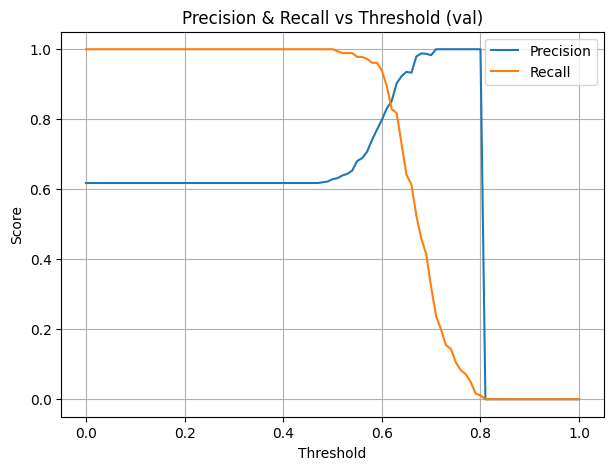

Limiar de interseção (|P-R| mínimo): 0.810
>>> Q3 — alternativa mais próxima: 0.745


In [14]:
# =========================
# Bloco 4 — Q3: Precisão vs Revocação (Precision x Recall) por limiar
# =========================

thresholds = np.arange(0.0, 1.0001, 0.01)
precisions, recalls = [], []

for t in thresholds:
    preds = (val_pred >= t).astype(int)
    # Para evitar warnings quando não há positivos preditos (precisão indefinida), use zero_division=0
    p = precision_score(y_val, preds, zero_division=0)
    r = recall_score(y_val, preds, zero_division=0)
    precisions.append(p)
    recalls.append(r)

precisions = np.array(precisions)
recalls = np.array(recalls)

# Plot
plt.figure(figsize=(7,5))
plt.plot(thresholds, precisions, label="Precision")
plt.plot(thresholds, recalls, label="Recall")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision & Recall vs Threshold (val)")
plt.legend()
plt.grid(True)
plt.show()

# Ponto de interseção: onde |P - R| é mínimo
idx_inter = np.argmin(np.abs(precisions - recalls))
thr_inter = thresholds[idx_inter]
print(f"Limiar de interseção (|P-R| mínimo): {thr_inter:.3f}")

opcoes_q3 = np.array([0.145, 0.345, 0.545, 0.745])
mais_proxima_q3 = opcoes_q3[np.argmin(np.abs(opcoes_q3 - thr_inter))]
print(f">>> Q3 — alternativa mais próxima: {mais_proxima_q3:.3f}")


# Q4

/tmp/ipykernel_3988/487830994.py:7: RuntimeWarning: invalid value encountered in divide
  f1_scores = np.where(den > 0, 2 * precisions * recalls / den, 0.0)


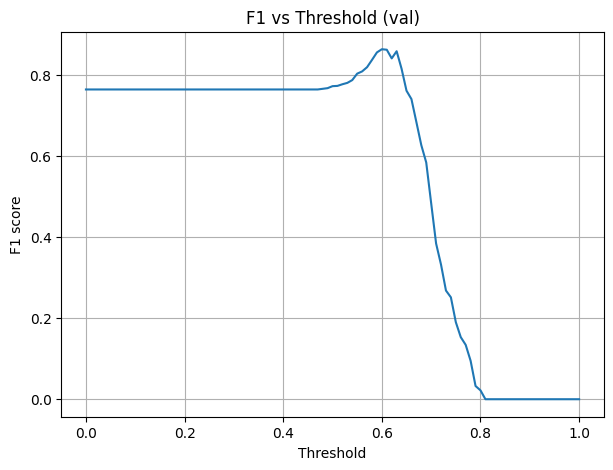

Melhor F1: 0.8629 no limiar 0.600
>>> Q4 — alternativa mais próxima (pelo limiar): 0.54
(Observação: acima escolhemos a alternativa com limiar mais próximo de 0.600)


In [15]:
# =========================
# Bloco 5 — Q4: F1 por limiar (0.00 a 1.00 passo 0.01)
# =========================

# F1 = 2PR/(P+R); se P+R==0, define 0
den = precisions + recalls
f1_scores = np.where(den > 0, 2 * precisions * recalls / den, 0.0)

idx_best = np.argmax(f1_scores)
thr_best_f1 = thresholds[idx_best]
best_f1 = f1_scores[idx_best]

plt.figure(figsize=(7,5))
plt.plot(thresholds, f1_scores)
plt.xlabel("Threshold")
plt.ylabel("F1 score")
plt.title("F1 vs Threshold (val)")
plt.grid(True)
plt.show()

print(f"Melhor F1: {best_f1:.4f} no limiar {thr_best_f1:.3f}")

opcoes_q4 = np.array([0.14, 0.34, 0.54, 0.74])
mais_proxima_q4 = opcoes_q4[np.argmin(np.abs(opcoes_q4 - thr_best_f1))]
print(f">>> Q4 — alternativa mais próxima (pelo limiar): {opcoes_q4[np.argmin(np.abs(opcoes_q4 - thr_best_f1))]:.2f}")
print(f"(Observação: acima escolhemos a alternativa com limiar mais próximo de {thr_best_f1:.3f})")


# Q5

In [16]:
# =========================
# Bloco 6 — Q5: Validação Cruzada 5-Fold (desvio-padrão das AUCs)
# =========================

# df_full_train = junção de train + val, y idem
df_full_train = pd.concat([df_train, df_val], axis=0).reset_index(drop=True)
y_full_train  = pd.concat([y_train,  y_val],  axis=0).reset_index(drop=True)

cat_cols_full = [c for c in df_full_train.columns if df_full_train[c].dtype == 'object']
num_cols_full = [c for c in df_full_train.columns if np.issubdtype(df_full_train[c].dtype, np.number)]

kfold = KFold(n_splits=5, shuffle=True, random_state=1)
auc_scores = []

for fold, (idx_tr, idx_va) in enumerate(kfold.split(df_full_train), 1):
    df_tr_f, df_va_f = df_full_train.iloc[idx_tr], df_full_train.iloc[idx_va]
    y_tr_f,  y_va_f  = y_full_train.iloc[idx_tr], y_full_train.iloc[idx_va]

    dv_f = DictVectorizer(sparse=True)
    X_tr_f = dv_f.fit_transform(df_tr_f[cat_cols_full + num_cols_full].to_dict(orient='records'))
    X_va_f = dv_f.transform(df_va_f[cat_cols_full + num_cols_full].to_dict(orient='records'))

    model_f = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000)
    model_f.fit(X_tr_f, y_tr_f)
    p_va_f = model_f.predict_proba(X_va_f)[:, 1]
    auc_f = roc_auc_score(y_va_f, p_va_f)
    auc_scores.append(auc_f)
    print(f"Fold {fold}: AUC={auc_f:.5f}")

auc_scores = np.array(auc_scores)
std_auc = auc_scores.std()
mean_auc = auc_scores.mean()
print(f"\nAUC média (5 folds): {mean_auc:.5f}")
print(f"Desvio-padrão: {std_auc:.5f}")

opcoes_q5 = np.array([0.0001, 0.006, 0.06, 0.36])
mais_proxima_q5 = opcoes_q5[np.argmin(np.abs(opcoes_q5 - std_auc))]
print(f">>> Q5 — alternativa mais próxima (std): {mais_proxima_q5:.4f}")


Fold 1: AUC=0.81810
Fold 2: AUC=0.83571
Fold 3: AUC=0.79915
Fold 4: AUC=0.82997
Fold 5: AUC=0.81420

AUC média (5 folds): 0.81943
Desvio-padrão: 0.01278
>>> Q5 — alternativa mais próxima (std): 0.0060


# Q6

In [17]:
# =========================
# Bloco 7 — Q6: Tuning de C (5-Fold CV)
# =========================

Cs = [0.000001, 0.001, 1]
kfold = KFold(n_splits=5, shuffle=True, random_state=1)

resultados = []

for C in Cs:
    scores = []
    for fold, (idx_tr, idx_va) in enumerate(kfold.split(df_full_train), 1):
        df_tr_f, df_va_f = df_full_train.iloc[idx_tr], df_full_train.iloc[idx_va]
        y_tr_f,  y_va_f  = y_full_train.iloc[idx_tr], y_full_train.iloc[idx_va]

        dv_f = DictVectorizer(sparse=True)
        X_tr_f = dv_f.fit_transform(df_tr_f.to_dict(orient='records'))
        X_va_f = dv_f.transform(df_va_f.to_dict(orient='records'))

        model_f = LogisticRegression(solver='liblinear', C=C, max_iter=1000)
        model_f.fit(X_tr_f, y_tr_f)
        p_va_f = model_f.predict_proba(X_va_f)[:, 1]
        scores.append(roc_auc_score(y_va_f, p_va_f))
    scores = np.array(scores)
    resultados.append((C, scores.mean(), scores.std()))

# imprime resultados (arredondados a 3 casas)
print("Resultados por C (média ± std):")
for C, m, s in resultados:
    print(f"  C={C}: mean={m:.3f}, std={s:.3f}")

# escolhe o melhor C: maior média; em empate, menor std; persistindo empate, menor C
resultados_sorted = sorted(resultados, key=lambda x: (-x[1], x[2], x[0]))
best_C, best_mean, best_std = resultados_sorted[0]

print(f"\n>>> Q6 — Melhor C: {best_C} (mean={best_mean:.3f}, std={best_std:.3f})")


Resultados por C (média ± std):
  C=1e-06: mean=0.565, std=0.050
  C=0.001: mean=0.862, std=0.015
  C=1: mean=0.819, std=0.013

>>> Q6 — Melhor C: 0.001 (mean=0.862, std=0.015)
